# 16S Analyses of the Longitudinal Acne Study
## Relative Abundance and Alpha Diversity Plots

Date created: 10/15/2024

Notebook authors: Yang Chen and Britta De Pessemier

Data analysis by: Tyler Myers, Britta De Pessemier, and Yang Chen

This notebook plots the following:

- 16S V1-V3 and V4 relative abundance plots at Genus taxon level
- 16S V1-V3 and V4 Shannon alpha diversity plots at Genus taxon level

In [205]:
# Import Python packages
import pandas as pd
import numpy as np
import biom
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
import os
from matplotlib.colors import ListedColormap
from matplotlib.colors import to_rgba


In [206]:
# Define the taxa level
taxa_level = 'Genus'

In [207]:
# Load the metadata
metadata_path = '../Metadata/metadata_final_22102024.tsv'
metadata = pd.read_csv(metadata_path, sep='\t')
metadata['severity_group'].value_counts()

low Acne_L         70
moderate Acne_L    64
absent Healthy     57
absent Acne_NL     27
high Acne_L        25
low Acne_NL        23
Name: severity_group, dtype: int64

In [208]:
# Define paths to the collapsed taxa tables
biom_paths = {
    'V1-V3': f'../Data/16S/Tables/16S_V1-V3_{taxa_level}_collapsed.biom',
    'V4': f'../Data/16S/Tables/16S_V4_{taxa_level}_collapsed.biom'
}

In [209]:
# Predefined color palette for specific families
if taxa_level == "Family":
    taxa_colors = {
        ' f__Propionibacteriaceae': '#ffa505',  # Bright orange
        ' f__Mycobacteriaceae': '#70a8dc',      # Blue
        ' f__Streptococcaceae': '#92f0f0',      # Fluorescent light blue
        ' f__Porphyromonodaceae': '#e2b46c',    # Beige
        ' f__Bacteroidaceae': '#ffe59a',        # Pastel yellow
        ' f__Neisseriaceae': '#f6475f',         # Pinkish
        ' f__Moraxellaceae': '#c5bce0',         # Pastel purplish
        ' f__Marinomonadaceae': '#f4cccd',  # Light pink
        ' f__Celerinatantimonadaceae': '#bcbcbc',  # Light gray
        ' f__Alteromonadaceae': '#daead3',  # Pale mint green
        'Others': '#ededed'                 # White
    }
elif taxa_level == "Genus":
    taxa_colors = {
        ' g__Cutibacterium': '#ffa505',  # Bright orange
        # ' g__uncultured': '#808080',      # Grey
        ' g__uncultured Neisseriaceae': '#f6475f',         # Pinkish
        ' g__Staphylococcus': '#92f0f0',      # Fluorescent light blue
        ' g__Streptococcus': '#e2b46c',    # Beige
        ' g__Corynebacterium': '#ffe59a',        # Pastel yellow
        ' g__Lawsonella': '#70a8dc',         # Light blue
        ' g__Veillonella': '#c5bce0',         # Pastel purplish
        ' g__Micrococcus':'#f4cccd',           # Pastel yellow
        ' g__Alloprevotella': '#bcbcbc',        # Light gray
        ' g__Lactobacillus': '#daead3',     # Pale mint green
        ' g__Neisseria': '#f6475f',         # Redish pink
        'Others': '#ededed'                 # White
    }

In [210]:
# A list of unique colors to use for taxa not predefined
unique_colors = sns.color_palette("deep", n_colors=20).as_hex()
unique_color_iter = cycle(unique_colors)  # Iterator to cycle through unique colors

In [211]:
# Function to load BIOM table, collapse by taxa, sort rows by row sum, remove specified samples, and convert to relative abundance
def load_biom_table(biom_path, metadata_path):
    # Load metadata as a DataFrame from the file path
    metadata = pd.read_csv(metadata_path, sep='\t')
    
    # Load BIOM table and convert to a DataFrame
    table = biom.load_table(biom_path)
    df = pd.DataFrame(table.matrix_data.toarray(),
                      index=table.ids(axis='observation'),
                      columns=table.ids(axis='sample'))
    
    # Replace 'uncultured' row with 'uncultured Neisseriaceae'
    df = df.rename(index={' g__uncultured': ' g__uncultured Neisseriaceae'})
    
    # Sort rows by row sum in descending order
    df['row_sum'] = df.sum(axis=1)
    df = df.sort_values(by='row_sum', ascending=False)
    
    # Drop the 'row_sum' column before proceeding
    df = df.drop(columns=['row_sum'])
    
    # Filter metadata based on specified conditions
    filtered_metadata = metadata[(metadata['group'] == 'low Acne_NL')]

    # Extract the SampleIDs to remove
    SampleIDs_to_drop = filtered_metadata['SampleID'].tolist()
    
    # Remove the columns from the DataFrame that correspond to these SampleIDs
    df = df.drop(columns=SampleIDs_to_drop, errors='ignore')  # Use 'ignore' in case some IDs are missing from the BIOM table

    # Convert the table to relative abundances
    df = df.div(df.sum(axis=0), axis=1)
    
    return df


In [212]:
# Function to determine the top 15 families and collapse the rest as "Others"
def collapse_top_15(df):
    top_families = df.sum(axis=1).nlargest(15).index  # Select top 15 families
    df_top = df.loc[top_families]
    df_top.loc['Others'] = df.loc[~df.index.isin(top_families)].sum()
    return df_top

In [213]:
# Function to get or assign colors to families
def get_taxa_colors(families, global_taxa_color_map):
    for taxa in families:
        if taxa not in global_taxa_color_map:
            if taxa in taxa_colors:
                global_taxa_color_map[taxa] = taxa_colors[taxa]
            else:
                global_taxa_color_map[taxa] = next(unique_color_iter)  # Assign a new unique color
    return global_taxa_color_map

In [214]:
def plot_relative_abundance(df, metadata, group_column, output_dir, biom_key, taxa_color_map):
    # Average by group
    df_grouped = df.groupby(metadata[group_column], axis=1).mean()

    # Reorder the columns to Healthy, Acne Non-lesional, and Acne Lesional Low, Mod, High severity
    # desired_order = ['absent Healthy', 'absent Acne_NL', 'low Acne_L', 'moderate Acne_L', 'high Acne_L']
    desired_order = ['Healthy', 'Acne_NL', 'Acne_L']

    df_grouped = df_grouped[desired_order]
    
    # Create output file paths
    output_png_file = os.path.join(output_dir, f'{biom_key}_{taxa_level}_relative_abundance_plot.png')  # Save as png
    output_svg_file = os.path.join(output_dir, f'{biom_key}_{taxa_level}_relative_abundance_plot.svg')  # Save as svg
    
    # Set plot title based on biom_key
    if biom_key == 'V1-V3':
        plot_title = f'16S rRNA (V1-V3) Relative Abundance'
    elif biom_key == 'V4':
        plot_title = f'16S rRNA (V4) Relative Abundance'
    else:
        plot_title = f'16S rRNA (V4) Relative Abundance'

    # Plot
    ax = df_grouped.T.plot(kind='bar', stacked=True, figsize=(13, 10),
                           width=0.8,  # Bars closer together
                           color=[taxa_color_map.get(fam, '#ADD8E6') for fam in df_grouped.index])

    plt.ylabel('Relative Abundance', fontsize=16)
    plt.xlabel(' ')
    plt.title(plot_title, fontsize=18)

    new_labels = ['Healthy\nSkin\n(n=57)', 'Acne\nNon-lesional\n(n=27)', 'Acne\nLesional\n(n=159)', ]

    # Set the new x-tick labels
    plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, ha='center', fontsize=16)

    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=14, title=taxa_level, title_fontsize=16)
    plt.tight_layout()

    plt.savefig(output_png_file, format='png', dpi=600)  # Save as png
    plt.savefig(output_svg_file, format='svg')  # Save as svg
    plt.show()

    plt.close()


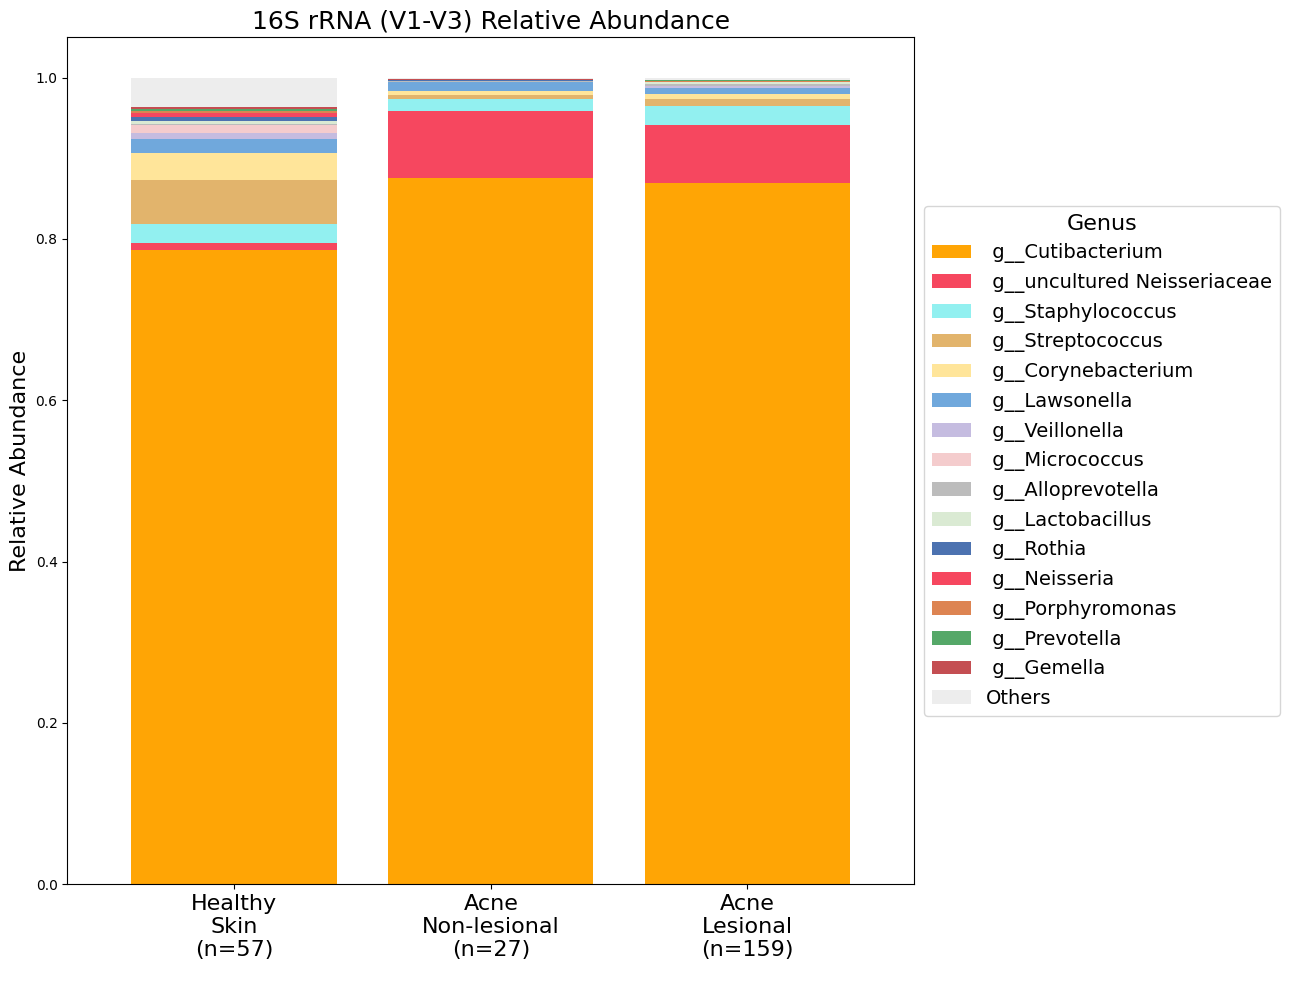

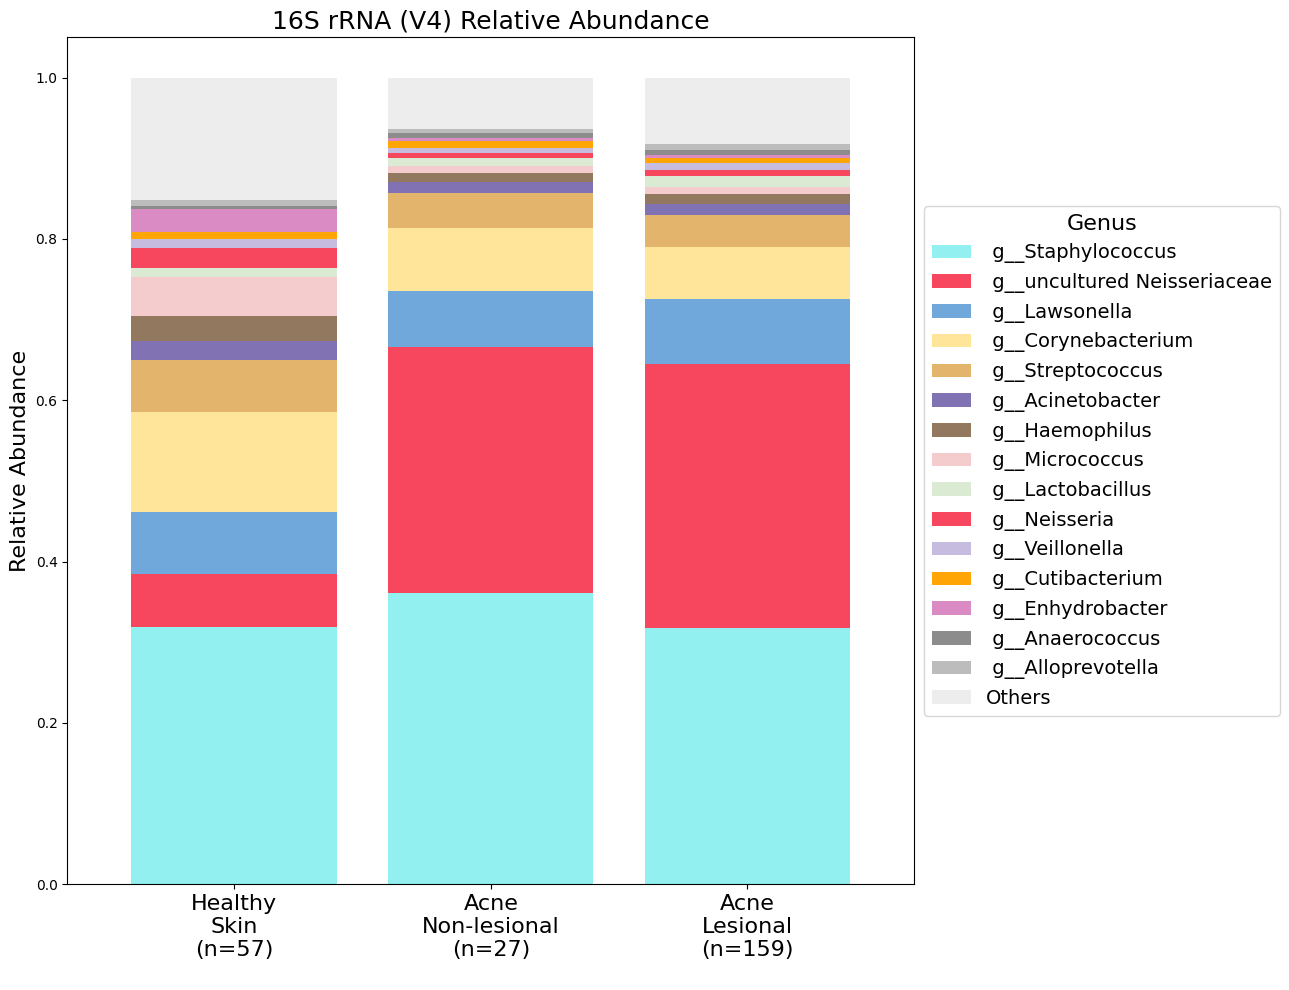

In [215]:
# Process both BIOM files
global_taxa_color_map = {}  # Store colors assigned to families across both datasets
for biom_key, biom_path in biom_paths.items():
    # Load and process the BIOM table
    df = load_biom_table(biom_path, metadata_path)
    df_top_15 = collapse_top_15(df)  # Now using the top 15 function
    
    # Define the output directory for the current biom_key
    output_dir = '../Figures/16S_Figures'
    os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists
    
    # Merge with metadata
    metadata_subset = metadata.set_index('SampleID').loc[df.columns]  # Assuming SampleID in metadata matches samples in BIOM table
    
    # Generate or retrieve colors for the top families in this dataset
    global_taxa_color_map = get_taxa_colors(df_top_15.index, global_taxa_color_map)
    
    # Plot the results and save in the respective folder 
    plot_relative_abundance(df_top_15, metadata_subset, 'group', output_dir, biom_key, global_taxa_color_map)

# 16S Analyses of the Longitudinal Acne Study
## Alpha Diversity Plots

In [216]:
# Additional Python packages for alpha diversity analyses
from skbio.diversity import alpha_diversity
from scipy.stats import mannwhitneyu

In [217]:
def darken_color(color, amount=0.3):
    """
    Darken a given color by a certain amount.
    
    Parameters:
    - color: The base color (as a hex string or color name).
    - amount: The amount to darken the color by (default: 0.3).
    
    Returns:
    - A darkened color as a hex string.
    """
    c = to_rgba(color)
    return (c[0] * (1 - amount), c[1] * (1 - amount), c[2] * (1 - amount), c[3])

In [218]:
def calculate_alpha_diversity_and_plot(biom_path, metadata_path, group_col, title_suffix):
    # Load metadata as a DataFrame from the file path
    metadata = pd.read_csv(metadata_path, sep='\t')
    metadata = metadata.set_index('SampleID')
    
    # Load biom table
    feature_table = load_biom_table(biom_path, metadata_path)

    # Transpose feature_table so rows are sample IDs
    feature_table = feature_table.transpose()

    # Calculate Shannon diversity
    shannon_values = alpha_diversity('shannon', feature_table.values, ids=feature_table.index)
    
    # Merge Shannon values with metadata
    common_samples = metadata.index.intersection(feature_table.index)
    metadata = metadata.loc[common_samples].copy()
    metadata['Shannon'] = shannon_values.loc[common_samples]
    
    # Set the custom order for the groups: Healthy first, then Acne Non-lesional, then Acne Lesional
    desired_order = ['Healthy', 'Acne_NL', 'Acne_L']

    # Set the color palette for the groups in the correct order
    palette = {
        'Healthy': '#3333B3',     # Dark Blue color for Healthy
        'Acne_NL': '#5cbccb',     # Blue color for Acne Non-Lesional
        'Acne_L': '#f16c52'       # Red color for Acne Lesional
    }

    # Create a new column for severity category based on local lesion severity
    metadata['severity_category'] = pd.cut(metadata['local_lesion_severity'],
                                        bins=[0, 2, 4, 6],  # Low (1-2), Moderate (3-4), High (5-6)
                                        labels=['low', 'moderate', 'high'])

    # Define a custom palette for severity categories within Acne_L group
    severity_palette = {
        'low': '#F1948A',      # Light red for low severity
        'moderate': '#EC7063',  # Red for moderate severity
        'high': '#C0392B'       # Dark red for high severity
    }

    # Create a more rectangular plot (e.g., 8 inches wide and 12 inches tall)
    plt.figure(figsize=(10, 10))

    # Plot the Shannon diversity across the groups using a boxplot with custom colors and order
    ax = sns.boxplot(x=group_col, y='Shannon', data=metadata, palette=palette, order=desired_order)

    # Darken the colors for the strip plot manually
    darker_palette = {key: darken_color(color) for key, color in palette.items()}

    # Plot the general stripplot with darkened colors
    sns.stripplot(x=group_col, y='Shannon', data=metadata, palette=darker_palette, jitter=True, dodge=False, ax=ax, linewidth=0.6, order=desired_order)

    # Add a second stripplot specifically for Acne_L, coloring by severity
    sns.stripplot(x=metadata[metadata[group_col] == 'Acne_L'][group_col], 
                  y=metadata[metadata[group_col] == 'Acne_L']['Shannon'], 
                  hue=metadata[metadata[group_col] == 'Acne_L']['severity_category'],
                  palette=severity_palette, jitter=True, dodge=False, ax=ax, linewidth=0.6)

    # Adjust the legend for the severity categories
    handles, labels = ax.get_legend_handles_labels()
    severity_handles = handles[-3:]  # Get the last three handles, which correspond to severity levels
    severity_labels = ['Low (1-2)', 'Moderate (3-4)', 'High (5-6)']  # Rename the labels

    # Move the legend outside the boxplot to the right
    ax.legend(severity_handles, severity_labels, title='Lesional Severity Score', 
            loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=True, title_fontsize=16, fontsize=14)

    # Add the title and labels
    plt.title(f'16S rRNA ({title_suffix}) Alpha Diversity', fontsize=18)
    plt.xlabel(' ')
    plt.ylabel('Shannon Index', fontsize=16)

    # Custom labels for the x-axis, following the same order
    new_labels = ['Healthy\nSkin\n(n=57)', 'Acne\nNon-lesional\n(n=27)', 'Acne\nLesional\n(n=159)']
    plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, ha='center', fontsize=16)

    # Pairwise significance testing using Mann-Whitney U test
    groups = ['Healthy', 'Acne_L', 'Acne_NL']
    p_values = {}
    
    # Heights to draw the annotation lines
    y_max = max(metadata['Shannon']) + 0.1
    height_step = 0.15  # Height step between lines
    
    # Perform pairwise comparisons
    for i, group1 in enumerate(groups):
        for j, group2 in enumerate(groups):
            if i < j:
                # Get the Shannon values for each group
                group1_values = metadata[metadata[group_col] == group1]['Shannon']
                group2_values = metadata[metadata[group_col] == group2]['Shannon']
                
                # Perform Mann-Whitney U test
                stat, p = mannwhitneyu(group1_values, group2_values, alternative='two-sided')
                p_values[f'{group1} vs {group2}'] = p
                
                # Determine the significance label based on p-value thresholds
                if p >= 0.05:
                    label = 'ns'
                elif p < 0.001:
                    label = '***'
                elif p < 0.01:
                    label = '**'
                else:
                    label = '*'
                
                # Get x coordinates of the boxplots
                x1, x2 = i, j
                y = y_max + height_step  # Vertical position for the horizontal line
                
                # Draw horizontal line and annotate the significance label
                plt.plot([x1, x1, x2, x2], [y, y + 0.01, y + 0.01, y], lw=1, color='black')
                plt.text((x1 + x2) * 0.5, y + 0.02, label, ha='center', va='bottom', fontsize=12)
                
                # Update y_max for the next comparison
                y_max += height_step + 0.05

    # Save the figure
    plt.savefig(f'../Figures/16S_Figures/{biom_key}_{taxa_level}_alpha-diversity.png', dpi=600, bbox_inches='tight', pad_inches=0.1)  # Save as png
    plt.savefig(f'../Figures/16S_Figures/{biom_key}_{taxa_level}_alpha-diversity.svg')  # Save as svg

    # Print pairwise p-values in scientific notation
    print("Pairwise Mann-Whitney U test p-values:")
    for comparison, p_value in p_values.items():
        print(f"{comparison}: p-value = {p_value:.2e}")


/var/folders/gg/tjf8z7kd7351mxr7fbw1s6j00000gp/T/ipykernel_30733/3201504174.py:52: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x=group_col, y='Shannon', data=metadata, palette=darker_palette, jitter=True, dodge=False, ax=ax, linewidth=0.6, order=desired_order)


Pairwise Mann-Whitney U test p-values:
Healthy vs Acne_L: p-value = 2.09e-04
Healthy vs Acne_NL: p-value = 1.82e-04
Acne_L vs Acne_NL: p-value = 8.58e-02


/var/folders/gg/tjf8z7kd7351mxr7fbw1s6j00000gp/T/ipykernel_30733/3201504174.py:52: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x=group_col, y='Shannon', data=metadata, palette=darker_palette, jitter=True, dodge=False, ax=ax, linewidth=0.6, order=desired_order)


Pairwise Mann-Whitney U test p-values:
Healthy vs Acne_L: p-value = 6.04e-06
Healthy vs Acne_NL: p-value = 5.71e-05
Acne_L vs Acne_NL: p-value = 6.73e-01


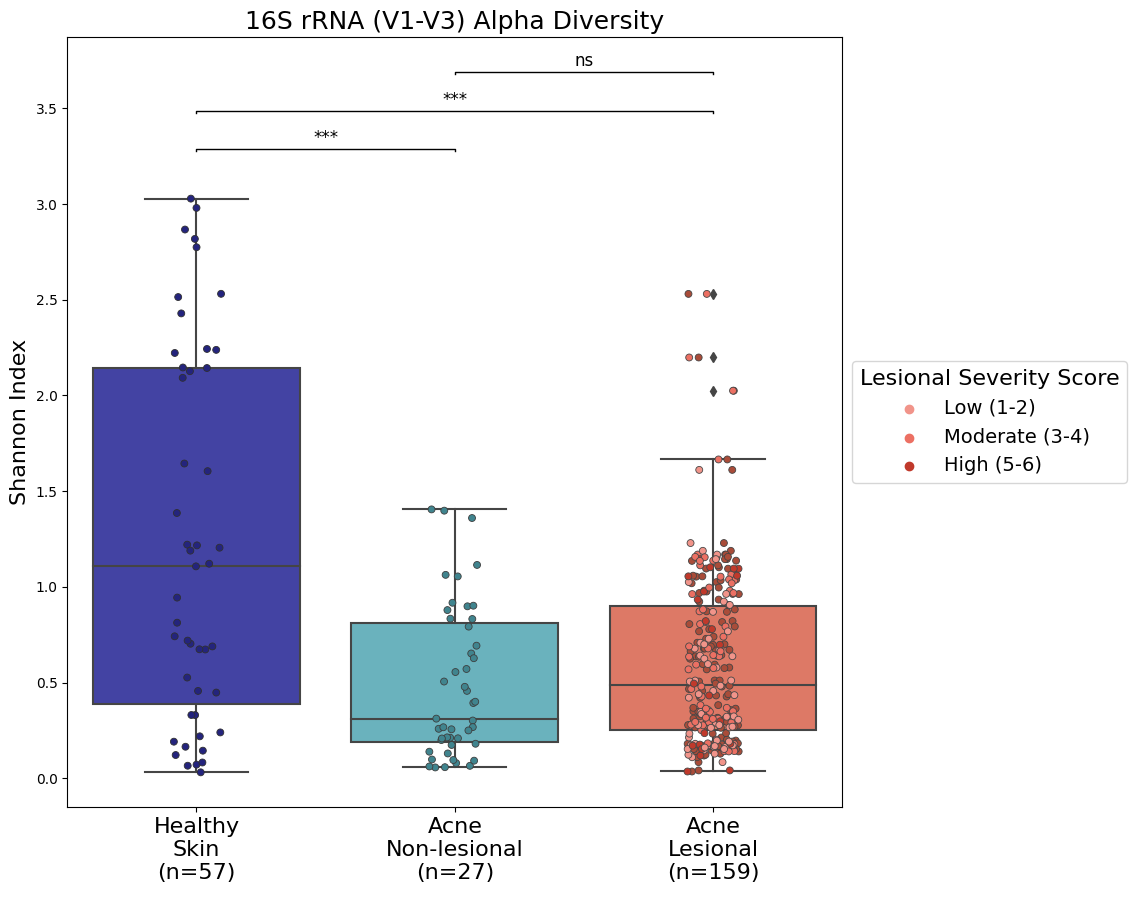

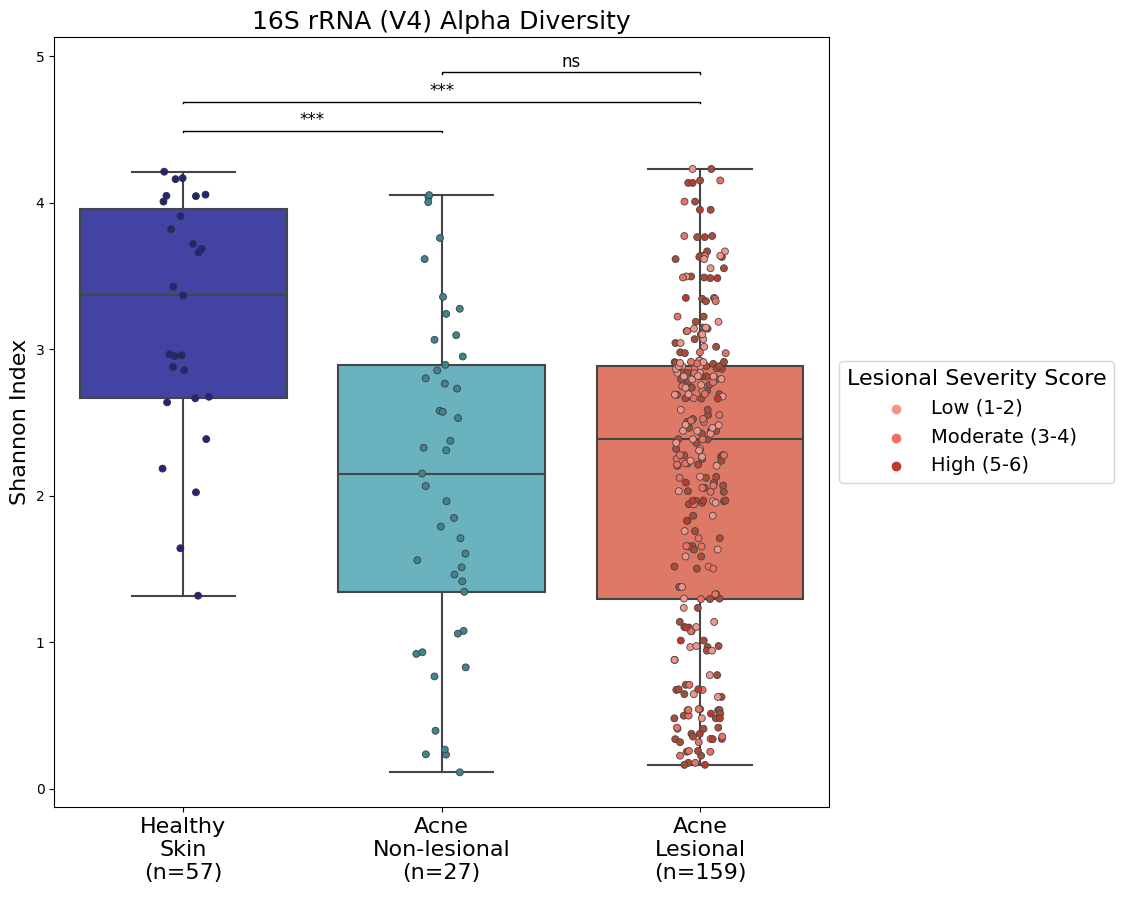

In [219]:
# Load metadata
metadata = pd.read_csv(metadata_path, sep='\t', index_col=0)

# Calculate and plot alpha diversity for both V1-V3 and V4 datasets
calculate_alpha_diversity_and_plot(biom_paths['V1-V3'], metadata_path, 'group', 'V1-V3')
calculate_alpha_diversity_and_plot(biom_paths['V4'], metadata_path, 'group', 'V4')